# 第 4 週:套件驗證收斂行為本身

**課程:計算力學方法論——驗證、確效與跨平台交叉比對**

第 3 週我們**手算**推導出 P1/P2 元素的收斂階數,並用 scikit-fem 驗證了「單一網格下」的節點值一致。
這週要驗證更強的東西:**收斂行為本身**——不是只驗證某個網格下答案一樣,而是完全丟開手算程式碼,
只用 scikit-fem,重跑一次第 3 週的整套收斂率實驗,看看獨立算出來的收斂階數是否還是同一組數字。

這週還要做一件新事情:**刻意去找套件裡「看不到但會影響結果」的預設值**——
不是為了挑套件的毛病,而是要示範一個習慣:交叉驗證通過之後,下一步該問「這個套件幫我做了哪些
我沒有明講的假設?」而不是直接信任到底。

## 1. 重建第 3 週的基準問題

沿用第 2、3 週的變係數桿件:$EA(x)=EA_0(1+x/L)$,$f(x)=f_0$。
符號解析解與其一階導數(稍後算能量範數誤差要用)重新建立一次。

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from skfem import MeshLine, ElementLineP1, ElementLineP2, Basis, BilinearForm, LinearForm, Functional, solve, condense

L_val, EA0_val, f0_val = 1.0, 100.0, 10.0

x, L, EA0, f0, C1, C2 = sp.symbols('x L EA0 f0 C1 C2', positive=True)
EA_expr = EA0 * (1 + x / L)
u_prime_expr = (-f0 * x + C1) / EA_expr
u_expr = sp.integrate(u_prime_expr, x) + C2
eq1 = sp.Eq(u_expr.subs(x, 0), 0)
eq2 = sp.Eq((-f0 * L + C1), 0)
sol = sp.solve([eq1, eq2], [C1, C2])
u_exact_sym = sp.simplify(u_expr.subs(sol))
up_exact_sym = sp.diff(u_exact_sym, x)

u_exact_func  = sp.lambdify(x, u_exact_sym.subs({L: L_val, EA0: EA0_val, f0: f0_val}), 'numpy')
up_exact_func = sp.lambdify(x, up_exact_sym.subs({L: L_val, EA0: EA0_val, f0: f0_val}), 'numpy')

def EA_func(xx):
    return EA0_val * (1 + xx / L_val)

print("(與第 2、3 週相同的符號解析解,不重複列印推導過程)")

(與第 2、3 週相同的符號解析解,不重複列印推導過程)


## 2. 純套件路徑:組裝與求解(不呼叫任何第 3 週的手算函式)

刻意包成通用函式,`ElemCls` 可以傳入 `ElementLineP1` 或 `ElementLineP2`,同一段程式碼服務兩種元素階數
——這也是套件相對手算的一個實務優勢:手算時 P1/P2 是兩段完全不同的程式碼,套件裡只是換一個參數。

In [2]:
def skfem_solve(n_elements, ElemCls):
    mesh = MeshLine(np.linspace(0, L_val, n_elements + 1))
    basis = Basis(mesh, ElemCls())

    @BilinearForm
    def a_form(u, v, w):
        return EA_func(w.x[0]) * u.grad[0] * v.grad[0]

    @LinearForm
    def L_form(v, w):
        return f0_val * v

    A_mat = a_form.assemble(basis)
    b_vec = L_form.assemble(basis)
    all_bnd = mesh.boundary_nodes()
    D = all_bnd[mesh.p[0, all_bnd] == 0.0]
    u = solve(*condense(A_mat, b_vec, D=D))
    return basis, u

## 3. 用套件自己的方式算誤差範數:`Functional`

第 3 週我們土法煉鋼,自己寫高斯積分迴圈算 $L^2$/能量範數誤差。
scikit-fem 提供 `@Functional` 裝飾器,可以直接對一個純量表達式在整個網格上積分——
這是套件的另一層抽象,這週順便學起來。

In [3]:
@Functional
def l2_error_sq(w):
    xg = w.x[0]
    return (w['uh'] - u_exact_func(xg))**2

@Functional
def energy_error_sq(w):
    xg = w.x[0]
    return EA_func(xg) * (w['uhp'] - up_exact_func(xg))**2

def skfem_errors(basis, u):
    uh = basis.interpolate(u)
    l2_sq = l2_error_sq.assemble(basis, uh=uh)
    e_sq  = energy_error_sq.assemble(basis, uhp=uh.grad[0])
    return np.sqrt(l2_sq), np.sqrt(e_sq)

# 快速檢查
b_chk, u_chk = skfem_solve(4, ElementLineP1)
l2_chk, e_chk = skfem_errors(b_chk, u_chk)
print(f"套件路徑 4元素 P1: L2誤差={l2_chk:.6e}, energy誤差={e_chk:.6e}")

套件路徑 4元素 P1: L2誤差=7.774904e-04, energy誤差=8.769040e-02


## 4. 完全獨立地重跑收斂率掃描

In [4]:
element_counts = [4, 8, 16, 32, 64]
results = {}

for label, ElemCls in [('P1', ElementLineP1), ('P2', ElementLineP2)]:
    hs, l2s, es = [], [], []
    for n in element_counts:
        basis, u = skfem_solve(n, ElemCls)
        l2, e = skfem_errors(basis, u)
        hs.append(L_val / n)
        l2s.append(l2)
        es.append(e)
    results[label] = {'h': hs, 'L2': l2s, 'energy': es}
    print(f"\n=== {label}(套件路徑)===")
    for n, h, l2, e in zip(element_counts, hs, l2s, es):
        print(f"n={n:3d}  h={h:.4f}  L2={l2:.6e}  energy={e:.6e}")

def fit_slope(h_list, err_list):
    return np.polyfit(np.log(h_list), np.log(err_list), 1)[0]

slopes = {label: (fit_slope(r['h'], r['L2']), fit_slope(r['h'], r['energy']))
          for label, r in results.items()}

print("\n=== 套件路徑擬合收斂階數 vs 第 3 週手算結果 ===")
print(f"{'':6}{'L2(套件)':>12}{'L2(第3週手算)':>16}{'energy(套件)':>16}{'energy(第3週手算)':>18}")
print(f"{'P1':6}{slopes['P1'][0]:12.3f}{1.988:16.3f}{slopes['P1'][1]:16.3f}{0.994:18.3f}")
print(f"{'P2':6}{slopes['P2'][0]:12.3f}{2.979:16.3f}{slopes['P2'][1]:16.3f}{1.983:18.3f}")


=== P1(套件路徑)===
n=  4  h=0.2500  L2=7.774904e-04  energy=8.769040e-02
n=  8  h=0.1250  L2=1.964077e-04  energy=4.410496e-02
n= 16  h=0.0625  L2=4.923377e-05  energy=2.208587e-02
n= 32  h=0.0312  L2=1.231676e-05  energy=1.104714e-02
n= 64  h=0.0156  L2=3.079711e-06  energy=5.524096e-03

=== P2(套件路徑)===
n=  4  h=0.2500  L2=1.295207e-05  energy=4.415725e-03
n=  8  h=0.1250  L2=1.645140e-06  energy=1.121460e-03
n= 16  h=0.0625  L2=2.065164e-07  energy=2.815189e-04
n= 32  h=0.0312  L2=2.584238e-08  energy=7.045286e-05
n= 64  h=0.0156  L2=3.231170e-09  energy=1.761780e-05

=== 套件路徑擬合收斂階數 vs 第 3 週手算結果 ===
            L2(套件)       L2(第3週手算)      energy(套件)     energy(第3週手算)
P1           1.995           1.988           0.997             0.994
P2           2.993           2.979           1.993             1.983


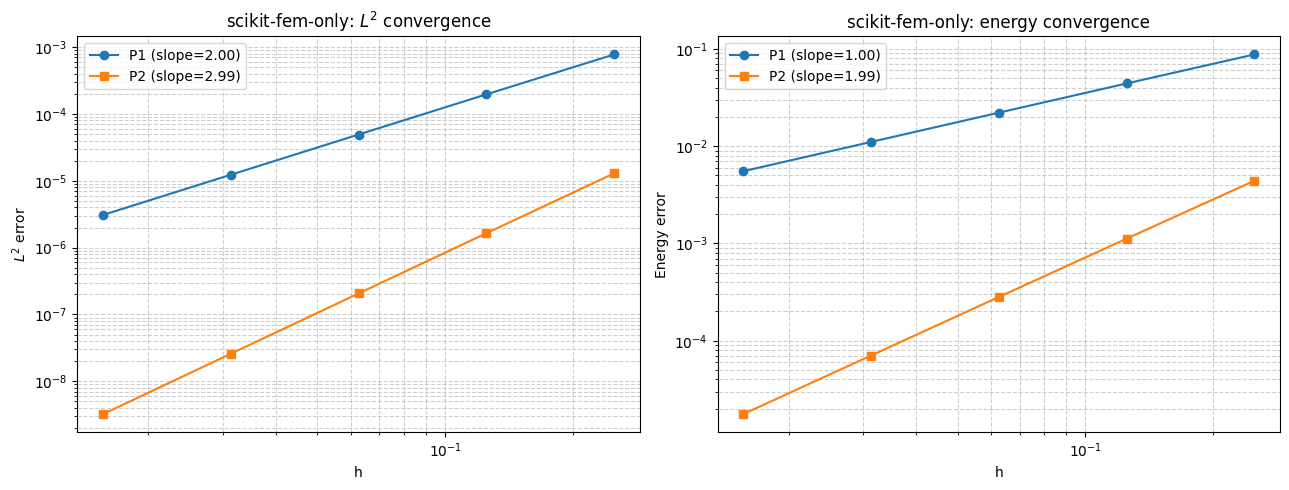

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label, marker in [('P1', 'o-'), ('P2', 's-')]:
    r = results[label]
    axes[0].loglog(r['h'], r['L2'], marker, label=f"{label} (slope={slopes[label][0]:.2f})")
    axes[1].loglog(r['h'], r['energy'], marker, label=f"{label} (slope={slopes[label][1]:.2f})")
axes[0].set_xlabel('h'); axes[0].set_ylabel('$L^2$ error'); axes[0].set_title('scikit-fem-only: $L^2$ convergence')
axes[1].set_xlabel('h'); axes[1].set_ylabel('Energy error'); axes[1].set_title('scikit-fem-only: energy convergence')
for ax in axes:
    ax.legend(); ax.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

## 5. 觀察:斜率一致,原始誤差數值卻有微小差異

擬合出來的收斂階數應該與第 3 週手算結果幾乎相同(差異在 0.01 量級以內)——**這才是這週真正驗證的東西:
收斂行為本身,不是某一個網格下的巧合**。

但如果你仔細比較同一個 `n_elements` 下的 `L2` 誤差**原始數值**,會發現套件路徑跟第 3 週手算路徑
並不是位元級相同,通常有幾個百分點的差異。這不是 bug,原因值得說清楚:

- 第 3 週手算誤差時,我們自己寫了 5 點高斯積分去逼近「$u_h$ 與解析解之差」的積分,解析解裡含有
  對數函數(非多項式),所以那個誤差範數本身也只是一個數值逼近,不是真值
- scikit-fem 的 `Functional` 積分,內部用的是套件自己選擇的積分階數,不一定跟我們手動選的 5 點高斯一樣

**收斂階數(斜率)是漸近行為,兩種獨立的誤差量測方式都會收斂到同一個斜率;但誤差的絕對數值,
本身依賴於「你怎麼定義/逼近這個誤差」這個選擇。** 這是一個值得記住的細節:交叉驗證要看的是
「結論(收斂階數)一不一致」,而不是要求每一個中間數字都位元對位元相同。

## 6. 套件裡藏著什麼:兩個值得知道的「看不見的預設值」

### 6.1 自由度(DOF)排序不一定按幾何順序

上週我們比較手算 P2 節點解與 `ElementLineP2` 節點解時,程式碼裡有一行不起眼的
`order = np.argsort(dof_coords)`。這不是隨手加的——scikit-fem 的 P2 自由度預設排序是
**先排所有頂點節點,再排所有邊中點節點**,不是照 $x$ 座標由左到右排。如果沒有排序就直接比較,
會得到完全對不起來、看似「套件算錯了」的結果。下面直接印出來看:

In [6]:
mesh_demo = MeshLine(np.linspace(0, 1, 5))  # 4 個元素
basis_demo = Basis(mesh_demo, ElementLineP2())
print("dof 座標(套件原始排序,注意不是由小到大):")
print(np.round(basis_demo.doflocs[0], 3))
print("\n排序後(由左到右,才對應到我們認知的『節點1,節點2,...』):")
print(np.round(np.sort(basis_demo.doflocs[0]), 3))

dof 座標(套件原始排序,注意不是由小到大):
[0.    0.25  0.5   0.75  1.    0.125 0.375 0.625 0.875]

排序後(由左到右,才對應到我們認知的『節點1,節點2,...』):
[0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875 1.   ]


### 6.2 積分階數(`intorder`)——我們試著弄壞它,沒有成功

scikit-fem 的 `Basis` 建構時可以手動指定 `intorder` 控制積分精度。理論上(Strang 定理,
1972 年的經典結果,俗稱「變分犯規 variational crimes」的分析)如果積分階數不夠高、沒辦法精確
積分被積函數,收斂階數會被積分誤差拖累,低於理論值。

我們刻意調低 `intorder`,想看看能不能重現這個「積分不夠精確拖垮收斂率」的現象:

In [7]:
def skfem_solve_intorder(n_elements, ElemCls, intorder):
    mesh = MeshLine(np.linspace(0, L_val, n_elements + 1))
    basis = Basis(mesh, ElemCls(), intorder=intorder)

    @BilinearForm
    def a_form(u, v, w):
        return EA_func(w.x[0]) * u.grad[0] * v.grad[0]

    @LinearForm
    def L_form(v, w):
        return f0_val * v

    A_mat = a_form.assemble(basis)
    b_vec = L_form.assemble(basis)
    all_bnd = mesh.boundary_nodes()
    D = all_bnd[mesh.p[0, all_bnd] == 0.0]
    u = solve(*condense(A_mat, b_vec, D=D))
    return basis, u

print("P2 元素,固定被積函數,只改變 intorder,量測收斂階數:")
for intorder in [1, 2, 3, 6]:
    hs, l2s = [], []
    for n in element_counts:
        basis, u = skfem_solve_intorder(n, ElementLineP2, intorder)
        l2, _ = skfem_errors(basis, u)
        hs.append(L_val / n); l2s.append(l2)
    slope = fit_slope(hs, l2s)
    print(f"intorder={intorder!s:>4}  L2 收斂斜率 = {slope:.3f}  (理論值 3)")

P2 元素,固定被積函數,只改變 intorder,量測收斂階數:
intorder=   1  L2 收斂斜率 = 2.991  (理論值 3)
intorder=   2  L2 收斂斜率 = 2.991  (理論值 3)
intorder=   3  L2 收斂斜率 = 2.991  (理論值 3)
intorder=   6  L2 收斂斜率 = 2.992  (理論值 3)


**結果:沒有壞掉。** 即使刻意把 `intorder` 壓到很低,收斂階數依然穩穩落在理論值附近。
這個「沒有壞掉」本身就是值得記錄的觀察,原因是:本題 $EA(x)$ 只是一次多項式(線性),
被積函數(勁度矩陣裡的 $EA\cdot B_iB_j$)本身次數不高,即使很低階的高斯積分也足以精確積分它
——不是 scikit-fem 特別聰明地保護了你,是這個測試案例的被積函數本來就沒有多難積分。

**這正是驗證方法論裡常被忽略的一點:一個「沒有出錯」的測試,不代表這個假設永遠成立,
可能只代表你選的測試案例不夠刁鑽。** 要真的暴露積分階數不足的問題,需要一個被積函數本身
變化更劇烈、或非多項式的係數(例如高頻震盪的 $EA(x)$),而且要在網格還沒充分加密、
單一元素內部包含好幾個震盪週期的情況下才會顯現——這正是下一節要示範的東西。

## 7. 額外示範:漸近前區間(pre-asymptotic regime)

先驗誤差估計裡「$O(h^p)$」這個記號,數學上的意思是「當 $h$ 夠小的時候」——如果網格還沒
細到解析出係數本身的變化尺度,擬合出來的收斂階數可能完全沒有意義。用一個高頻震盪的
$EA(x) = EA_0\big(1+0.9\sin(2\pi n_{osc}x/L)\big)$ 示範這件事(此處解析解不再是初等函數,
改用 `scipy.integrate.quad` 高精度數值積分作為參考「真值」)。

In [8]:
from scipy.integrate import quad

n_osc = 4  # 沿桿件長度震盪 4 個週期

def EA_osc(xx):
    return EA0_val * (1 + 0.9*np.sin(2*np.pi*n_osc*xx/L_val))

# EA(L)u'(L)=0 恆給出 u'(L)=0,與 EA(x) 形狀無關,故 C1 = f0*L
def uprime_osc(s):
    return (f0_val*(L_val - s)) / EA_osc(s)

def u_exact_osc_scalar(xx):
    val, _ = quad(uprime_osc, 0, xx, limit=200)
    return val

u_exact_osc = np.vectorize(u_exact_osc_scalar)

def skfem_solve_osc(n_elements):
    mesh = MeshLine(np.linspace(0, L_val, n_elements + 1))
    basis = Basis(mesh, ElementLineP1())
    @BilinearForm
    def a_form(u, v, w):
        return EA_osc(w.x[0]) * u.grad[0] * v.grad[0]
    @LinearForm
    def L_form(v, w):
        return f0_val * v
    A_mat = a_form.assemble(basis)
    b_vec = L_form.assemble(basis)
    all_bnd = mesh.boundary_nodes()
    D = all_bnd[mesh.p[0, all_bnd] == 0.0]
    u = solve(*condense(A_mat, b_vec, D=D))
    dofc = mesh.p[0]
    order = np.argsort(dofc)
    return dofc[order], u[order]

print(f"{'n_elem':>8}{'elem/oscillation':>18}{'max node error':>18}")
osc_errors = []
osc_ns = [4, 8, 16, 32, 64, 128]
for n in osc_ns:
    nodes, u = skfem_solve_osc(n)
    err = np.max(np.abs(u - u_exact_osc(nodes)))
    osc_errors.append(err)
    print(f"{n:8d}{n/n_osc:18.2f}{err:18.4e}")

  n_elem  elem/oscillation    max node error
       4              1.00        5.4486e-02
       8              2.00        3.7285e-02
      16              4.00        3.5476e-02
      32              8.00        1.2097e-02
      64             16.00        2.7325e-03
     128             32.00        6.8335e-04


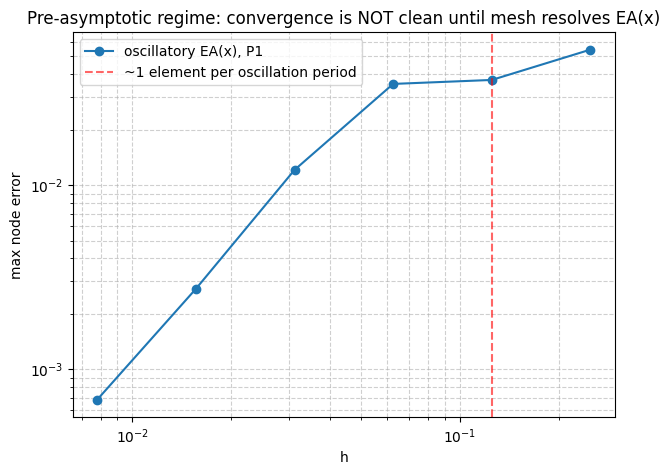

In [9]:
plt.figure(figsize=(7, 5))
plt.loglog(L_val/np.array(osc_ns), osc_errors, 'o-', label='oscillatory EA(x), P1')
plt.axvline(L_val/(2*n_osc), color='r', linestyle='--', alpha=0.6,
            label='~1 element per oscillation period')
plt.xlabel('h'); plt.ylabel('max node error')
plt.title('Pre-asymptotic regime: convergence is NOT clean until mesh resolves EA(x)')
plt.legend(); plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.show()

看誤差數字(不是只看圖):在 `n_elem` 還小、平均每個元素連一個完整震盪週期都涵蓋不到的時候,
誤差下降並不乾淨(不是穩定的等比例下降)。只有當元素數量夠多、每個元素能夠解析 $EA(x)$ 的震盪尺度之後,
誤差才開始呈現乾淨的冪次下降。**如果你在這個「漸近前區間」硬是對兩三個粗網格點做 log-log 線性擬合,
算出來的斜率是沒有物理意義的數字**——這正好回答了第 3 週討論題 4 埋下的伏筆。

## 8. 討論題(課堂/作業)

1. 把 `n_osc` 從 4 提高到 16,重跑第 7 節的實驗。需要多細的網格(`n_elements` 大約要多少),
   誤差才會開始呈現乾淨的冪次下降?這個「夠細」的門檻,跟 `n_osc` 之間大概是什麼關係?
2. 第 6.2 節我們沒能用 `intorder` 弄壞收斂率。試著把本題的 $EA(x)$ 換成非多項式但**不震盪**
   的函數,例如 $EA(x)=EA_0\exp(x/L)$,固定一個中等網格(例如 `n_elements=8`),只改變
   `intorder` 從 1 掃到 20,看看誤差有沒有隨 `intorder` 明顯變化。如果還是沒有明顯效果,
   想想看為什麼——這跟被積函數在單一元素內部變化的劇烈程度有沒有關係?
3. 回顧 6.1 節的 DOF 排序陷阱。如果今天你不是自己手算 P2,而是直接用 scikit-fem 算出位移場後,
   想把數值結果存成一個 CSV 檔案給不懂 FEM 的同事畫圖,你會在程式碼的哪一步驟加上排序,
   避免同事拿到一份看起來「資料是亂的」的檔案?
4. 這週我們用「收斂階數是否一致」作為交叉驗證通過的標準,而不要求誤差絕對值位元對位元相同。
   如果哪天你在做交叉驗證,兩種方法的收斂階數一致,但誤差絕對值差了 10 倍(不是幾個百分點),
   你會認為這還算「驗證通過」嗎?怎麼進一步判斷這 10 倍的差異是「誤差定義不同」還是
   「某處真的有問題」?

## 下週預告

第 5 週正式從桿件(只有軸向拉伸的一維自由度)跨到樑元素——多了撓度與轉角自由度、
Hermite 三次形狀函數、彎矩與剪力。同一套「手算 + 套件反向驗證 + 收斂率分析」的框架會被
完整地搬過去一次,作為檢驗這套方法論是否只是「桿件的巧合」,還是真的可以推廣的第一個測試。